In [1]:
# CELL 1 — Setup

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

PROJECT_PATH = "/content/drive/MyDrive/BRFSS_Project"

print("Connected.")

Mounted at /content/drive
Connected.


In [2]:
# CELL 2 — Load preprocessed data

with open(f"{PROJECT_PATH}/clean_data/study_b_preprocessed.pkl", 'rb') as f:
    data = pickle.load(f)

X_train = data['X_dense_train_scaled']
X_test = data['X_dense_test_scaled']
y_train = data['y_train']
y_test = data['y_test']
DENSE_COLS = data['DENSE_COLS']
sub_test = data['sub_test']
scale_pos_weight = data['scale_pos_weight']

X_train_df = pd.DataFrame(X_train, columns=DENSE_COLS)
X_test_df = pd.DataFrame(X_test, columns=DENSE_COLS)

print(f"X_train: {X_train_df.shape}")
print(f"X_test:  {X_test_df.shape}")
print(f"y_train positive rate: {y_train.mean()*100:.1f}%")
print(f"y_test  positive rate: {y_test.mean()*100:.1f}%")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")
print(f"\nFeature columns ({len(DENSE_COLS)}):")
print(DENSE_COLS)

X_train: (359611, 54)
X_test:  (89903, 54)
y_train positive rate: 13.9%
y_test  positive rate: 13.9%
scale_pos_weight: 6.21

Feature columns (54):
['ACE_SCORE', 'HIGH_ACE', 'ACE_MISSING', 'ACE_MODULE_MISSING', 'ACE_HH_DYSFUNCTION', 'ACE_DIRECT_ABUSE', 'ACE_SEXUAL_ABUSE', 'ACEADSAF', 'ACEADNED', 'LONELINESS', 'LOW_SUPPORT', 'LIFE_DISSATISFIED', 'SDHEMPLY', 'FOODSTMP', 'FOOD_INSECURE', 'SDHBILLS', 'SDHUTILS', 'SDHTRNSP', 'MEDCOST1', 'UNSAFE_NEIGHBORHOOD', 'HARDSHIP_INDEX', 'SEX_FEMALE', 'AGE_GROUP', 'EDUCATION', 'INCOME', 'MARRIED', 'NEVER_MARRIED', 'VETERAN3', 'HAS_CHILDREN', 'URBAN', '_HISPANC', 'PHYS_INACTIVE', 'CURRENT_SMOKER', 'FORMER_SMOKER', 'BINGE_DRINK', 'HEAVY_DRINK', 'MARIJAN1', 'CHECKUP_RECENT', '_HLTHPL2', 'HAS_DOCTOR', 'GENHLTH', 'OVERWEIGHT_OBESE', 'ADDEPEV3', 'DIABETE4', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'CHCCOPD3', 'HAVARTH4', 'CHCKDNY2', 'ASTHMA3', 'ANY_DISABILITY', 'MULTIMORBIDITY', 'CAREGIV1']


In [3]:
# CELL 3 — Imports

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, average_precision_score,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt

In [4]:
# CELL 4 — Shared evaluation function

def evaluate_model(name, model, X_test, y_test):
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)

    auc = roc_auc_score(y_test, y_pred_proba)
    ap = average_precision_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred)

    print("=" * 50)
    print(f"{name} — TEST SET RESULTS")
    print("=" * 50)
    print(f"AUC-ROC: {auc:.4f}")
    print(f"PR-AUC:  {ap:.4f}")
    print(f"F1:      {f1:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=['No Distress', 'Frequent Distress']))

    return {
        'auc_roc': round(auc, 4),
        'pr_auc': round(ap, 4),
        'f1': round(f1, 4),
        'y_pred_proba': y_pred_proba.tolist(),
        'y_pred': y_pred.tolist(),
    }

In [5]:
# CELL 5 — Logistic Regression

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    random_state=42
)
lr.fit(X_train_df, y_train)

lr_results = evaluate_model('Logistic Regression', lr, X_test_df, y_test)

Logistic Regression — TEST SET RESULTS
AUC-ROC: 0.8397
PR-AUC:  0.5182
F1:      0.4897

                   precision    recall  f1-score   support

      No Distress       0.95      0.80      0.87     77440
Frequent Distress       0.37      0.74      0.49     12463

         accuracy                           0.79     89903
        macro avg       0.66      0.77      0.68     89903
     weighted avg       0.87      0.79      0.81     89903



In [6]:
# CELL 6 — Random Forest

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_df, y_train)

rf_results = evaluate_model('Random Forest', rf, X_test_df, y_test)

Random Forest — TEST SET RESULTS
AUC-ROC: 0.8414
PR-AUC:  0.5214
F1:      0.4924

                   precision    recall  f1-score   support

      No Distress       0.95      0.80      0.87     77440
Frequent Distress       0.37      0.74      0.49     12463

         accuracy                           0.79     89903
        macro avg       0.66      0.77      0.68     89903
     weighted avg       0.87      0.79      0.82     89903



In [7]:
# CELL 7 — XGBoost

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)
xgb.fit(X_train_df, y_train)

xgb_results = evaluate_model('XGBoost', xgb, X_test_df, y_test)

XGBoost — TEST SET RESULTS
AUC-ROC: 0.8488
PR-AUC:  0.5361
F1:      0.4980

                   precision    recall  f1-score   support

      No Distress       0.95      0.80      0.87     77440
Frequent Distress       0.37      0.75      0.50     12463

         accuracy                           0.79     89903
        macro avg       0.66      0.77      0.68     89903
     weighted avg       0.87      0.79      0.82     89903



In [8]:
# CELL 8 — SAVE RESULTS TO model_results.pkl


results_path = f"{PROJECT_PATH}/clean_data/model_results.pkl"

try:
    with open(results_path, 'rb') as f:
        model_results = pickle.load(f)
    print("Loaded existing model_results.pkl from Gia.")
except FileNotFoundError:
    model_results = {}
    print("No existing model_results.pkl found — creating new.")

model_results['Logistic Regression'] = lr_results
model_results['Random Forest'] = rf_results
model_results['XGBoost'] = xgb_results

with open(results_path, 'wb') as f:
    pickle.dump(model_results, f)

print(f"\nSaved model_results.pkl")
print(f"Models now in pkl: {list(model_results.keys())}")

Loaded existing model_results.pkl from Gia.

Saved model_results.pkl
Models now in pkl: ['Hybrid LSTM', 'Logistic Regression', 'Random Forest', 'XGBoost']


In [9]:
# CELL 9 — COMPARISON TABLE


print("=" * 60)
print("STUDY B MODEL COMPARISON TABLE")
print("=" * 60)
print(f"  {'Model':<25} | {'AUC-ROC':>7} | {'PR-AUC':>7} | {'F1':>6}")
print(f"  {'-'*55}")
for model_name, res in model_results.items():
    print(f"  {model_name:<25} | {res['auc_roc']:>7.4f} | {res['pr_auc']:>7.4f} | {res['f1']:>6.4f}")

STUDY B MODEL COMPARISON TABLE
  Model                     | AUC-ROC |  PR-AUC |     F1
  -------------------------------------------------------
  Hybrid LSTM               |  0.8490 |  0.5362 | 0.4923
  Logistic Regression       |  0.8397 |  0.5182 | 0.4897
  Random Forest             |  0.8414 |  0.5214 | 0.4924
  XGBoost                   |  0.8488 |  0.5361 | 0.4980


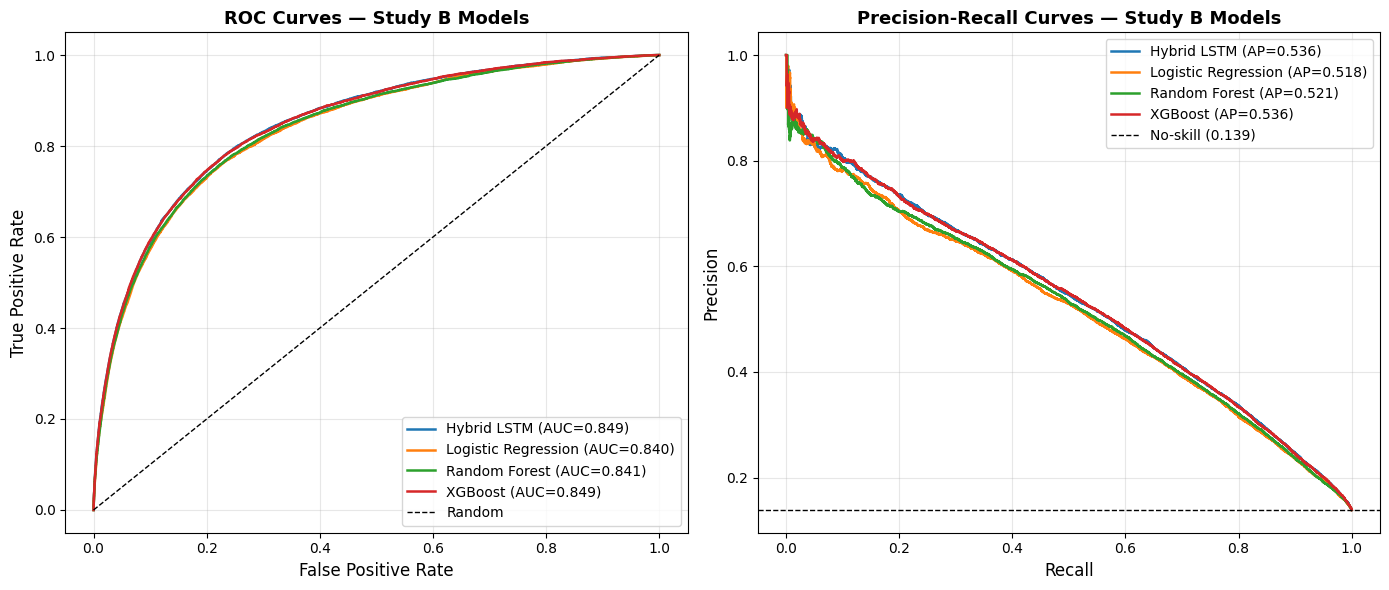

Curves saved.


In [10]:
# CELL 10 — ROC Curves and Precision-Recall Curves


from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC
ax = axes[0]
for model_name, res in model_results.items():
    y_proba = np.array(res['y_pred_proba'])
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{model_name} (AUC={res['auc_roc']:.3f})", linewidth=1.8)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Study B Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# PR
ax = axes[1]
baseline_prev = y_test.mean()
for model_name, res in model_results.items():
    y_proba = np.array(res['y_pred_proba'])
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = res['pr_auc']
    ax.plot(rec, prec, label=f"{model_name} (AP={ap:.3f})", linewidth=1.8)

ax.axhline(y=baseline_prev, color='k', linestyle='--', linewidth=1,
           label=f'No-skill ({baseline_prev:.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — Study B Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/clean_data/baseline_roc_pr_curves.png",
            dpi=150, bbox_inches='tight')
plt.show()

print("Curves saved.")

In [11]:
# CELL 11 — Build subgroup dataframe for fairness analysis


sub = sub_test.reset_index(drop=True).copy()
sub['y_true'] = y_test

sub['y_proba_lr'] = lr_results['y_pred_proba']
sub['y_proba_rf'] = rf_results['y_pred_proba']
sub['y_proba_xgb'] = xgb_results['y_pred_proba']

sub['y_pred_lr'] = lr_results['y_pred']
sub['y_pred_rf'] = rf_results['y_pred']
sub['y_pred_xgb'] = xgb_results['y_pred']

if 'Hybrid LSTM' in model_results:
    sub['y_proba_lstm'] = model_results['Hybrid LSTM']['y_pred_proba']
    sub['y_pred_lstm'] = model_results['Hybrid LSTM']['y_pred']
    MODEL_COLS = {
        'Logistic Regression': ('y_proba_lr', 'y_pred_lr'),
        'Random Forest': ('y_proba_rf', 'y_pred_rf'),
        'XGBoost': ('y_proba_xgb', 'y_pred_xgb'),
        'Hybrid LSTM': ('y_proba_lstm', 'y_pred_lstm'),
    }
else:
    MODEL_COLS = {
        'Logistic Regression': ('y_proba_lr', 'y_pred_lr'),
        'Random Forest': ('y_proba_rf', 'y_pred_rf'),
        'XGBoost': ('y_proba_xgb', 'y_pred_xgb'),
    }

print("Subgroup columns available:")
print(sub.columns.tolist())
print(f"\nTest set rows: {len(sub):,}")

Subgroup columns available:
['_STATE', '_LLCPWT', '_AGEG5YR', '_RACEGR3', '_INCOMG1', 'HIGH_ACE', 'ADDEPEV3', 'y_true', 'y_proba_lr', 'y_proba_rf', 'y_proba_xgb', 'y_pred_lr', 'y_pred_rf', 'y_pred_xgb', 'y_proba_lstm', 'y_pred_lstm']

Test set rows: 89,903


In [12]:
# CELL 12 — Disaggregated evaluation helpers


def disaggregated_eval(sub_df, group_col, group_labels, model_cols, min_n=200, min_pos=30):
    results = []
    for code, label in group_labels.items():
        mask = sub_df[group_col] == code
        grp = sub_df[mask]

        if len(grp) < min_n:
            continue
        if grp['y_true'].sum() < min_pos:
            continue

        row = {
            'group': label,
            'n': len(grp),
            'prevalence': round(grp['y_true'].mean() * 100, 1),
        }

        for model_name, (proba_col, pred_col) in model_cols.items():
            if proba_col not in grp.columns:
                continue
            g_auc = roc_auc_score(grp['y_true'], grp[proba_col])
            g_f1 = f1_score(grp['y_true'], grp[pred_col])
            row[f'{model_name}_AUC'] = round(g_auc, 4)
            row[f'{model_name}_F1'] = round(g_f1, 4)

        results.append(row)

    return pd.DataFrame(results)

def print_fairness_table(df, metric='AUC'):
    metric_cols = [c for c in df.columns if c.endswith(f'_{metric}')]
    display_cols = ['group', 'n', 'prevalence'] + metric_cols
    display_cols = [c for c in display_cols if c in df.columns]
    print(df[display_cols].to_string(index=False))

In [13]:
# CELL 13 — Fairness by Race/Ethnicity


race_labels = {
    1: 'White (non-Hispanic)',
    2: 'Black (non-Hispanic)',
    3: 'Hispanic',
    4: 'Asian / Pacific Islander',
    5: 'Other / Multiracial',
    9: 'Unknown / Missing',
}

if '_RACEGR3' in sub.columns:
    print("=" * 65)
    print("DISAGGREGATED PERFORMANCE — Race/Ethnicity")
    print("=" * 65)

    race_df = disaggregated_eval(sub, '_RACEGR3', race_labels, MODEL_COLS)

    print("\nAUC-ROC by Race:")
    print_fairness_table(race_df, 'AUC')
    print("\nF1 by Race:")
    print_fairness_table(race_df, 'F1')

    for model_name in MODEL_COLS.keys():
        col = f'{model_name}_AUC'
        if col in race_df.columns:
            auc_range = race_df[col].max() - race_df[col].min()
            print(f"\n{model_name} — AUC gap across race groups: {auc_range:.4f}")
            if auc_range > 0.05:
                print("Gap > 0.05 — notable disparity worth discussing")
else:
    print("_RACEGR3 not found in sub_test.")

DISAGGREGATED PERFORMANCE — Race/Ethnicity

AUC-ROC by Race:
                   group     n  prevalence  Logistic Regression_AUC  Random Forest_AUC  XGBoost_AUC  Hybrid LSTM_AUC
    White (non-Hispanic) 64738        13.3                   0.8482             0.8492       0.8572           0.8571
    Black (non-Hispanic)  7069        15.2                   0.8123             0.8164       0.8195           0.8227
                Hispanic  4846        14.2                   0.8223             0.8212       0.8235           0.8261
Asian / Pacific Islander  2035        22.6                   0.8227             0.8222       0.8338           0.8337
     Other / Multiracial  9501        14.6                   0.8120             0.8165       0.8230           0.8239
       Unknown / Missing  1714        13.0                   0.8316             0.8365       0.8386           0.8393

F1 by Race:
                   group     n  prevalence  Logistic Regression_F1  Random Forest_F1  XGBoost_F1  Hybrid LS

In [14]:
# CELL 14 — Fairness by Sex


sex_labels = {1: 'Male', 2: 'Female'}

if 'SEXVAR' in sub.columns:
    print("\n" + "=" * 65)
    print("DISAGGREGATED PERFORMANCE — Sex")
    print("=" * 65)

    sex_df = disaggregated_eval(sub, 'SEXVAR', sex_labels, MODEL_COLS)

    print("\nAUC-ROC by Sex:")
    print_fairness_table(sex_df, 'AUC')
    print("\nF1 by Sex:")
    print_fairness_table(sex_df, 'F1')
else:
    print("Sex variable not available in Study B dataset.")

SEXVAR not found in sub_test.


In [15]:
# CELL 15 — Fairness by Income Level


income_labels = {
    1: '<$15k',
    2: '$15–25k',
    3: '$25–35k',
    4: '$35–50k',
    5: '$50–75k',
    6: '$75–100k',
    7: '$100–150k',
    8: '$150–200k',
    9: '$200k+',
}

if '_INCOMG1' in sub.columns:
    sub_income = sub[sub['_INCOMG1'] != 9].copy()

    print("\n" + "=" * 65)
    print("DISAGGREGATED PERFORMANCE — Income Level")
    print("=" * 65)

    inc_df = disaggregated_eval(sub_income, '_INCOMG1', income_labels, MODEL_COLS)

    print("\nAUC-ROC by Income:")
    print_fairness_table(inc_df, 'AUC')
    print("\nF1 by Income:")
    print_fairness_table(inc_df, 'F1')

    for model_name in MODEL_COLS.keys():
        col = f'{model_name}_AUC'
        if col in inc_df.columns:
            auc_range = inc_df[col].max() - inc_df[col].min()
            print(f"\n{model_name} — AUC gap across income groups: {auc_range:.4f}")
else:
    print("_INCOMG1 not found in sub_test.")


DISAGGREGATED PERFORMANCE — Income Level

AUC-ROC by Income:
    group     n  prevalence  Logistic Regression_AUC  Random Forest_AUC  XGBoost_AUC  Hybrid LSTM_AUC
    <$15k  4039        28.6                   0.8281             0.8286       0.8340           0.8356
  $15–25k  6614        23.0                   0.8434             0.8442       0.8478           0.8498
  $25–35k  8125        17.8                   0.8297             0.8316       0.8393           0.8401
  $35–50k  9804        16.0                   0.8195             0.8224       0.8308           0.8309
  $50–75k 22312        12.1                   0.8326             0.8334       0.8425           0.8417
 $75–100k 16474         9.3                   0.8187             0.8212       0.8321           0.8308
$100–150k  5943         7.3                   0.8062             0.8114       0.8229           0.8211

F1 by Income:
    group     n  prevalence  Logistic Regression_F1  Random Forest_F1  XGBoost_F1  Hybrid LSTM_F1
    <$15k

In [16]:
# CELL 16 — Fairness by ACE Burden


ace_labels = {
    0: 'Low ACE (0–3)',
    1: 'High ACE (4+)',
}

if 'HIGH_ACE' in sub.columns:
    print("\n" + "=" * 65)
    print("DISAGGREGATED PERFORMANCE — ACE Burden")
    print("=" * 65)

    ace_df = disaggregated_eval(sub, 'HIGH_ACE', ace_labels, MODEL_COLS,
                                min_n=100, min_pos=20)

    print("\nAUC-ROC by ACE Burden:")
    print_fairness_table(ace_df, 'AUC')
    print("\nF1 by ACE Burden:")
    print_fairness_table(ace_df, 'F1')

    if 'Hybrid LSTM' in MODEL_COLS:
        lstm_col = 'Hybrid LSTM_AUC'
        xgb_col = 'XGBoost_AUC'
        if lstm_col in ace_df.columns and xgb_col in ace_df.columns:
            lstm_gap = ace_df[lstm_col].max() - ace_df[lstm_col].min()
            xgb_gap = ace_df[xgb_col].max() - ace_df[xgb_col].min()

            print(f"\nAUC gap (High vs Low ACE):")
            print(f"XGBoost AUC gap: {xgb_gap:.4f}")
            print(f"Hybrid LSTM AUC gap: {lstm_gap:.4f}")

            if lstm_gap < xgb_gap:
                print("Hybrid LSTM shows smaller gap — more equitable across ACE burden.")
            else:
                print("Hybrid LSTM shows larger gap — may need further investigation.")
else:
    print("HIGH_ACE not found in sub_test.")


DISAGGREGATED PERFORMANCE — ACE Burden

AUC-ROC by ACE Burden:
        group    n  prevalence  Logistic Regression_AUC  Random Forest_AUC  XGBoost_AUC  Hybrid LSTM_AUC
Low ACE (0–3) 6382         9.9                   0.8243             0.8233       0.8296           0.8335
High ACE (4+) 1419        27.8                   0.8020             0.7954       0.8010           0.8075

F1 by ACE Burden:
        group    n  prevalence  Logistic Regression_F1  Random Forest_F1  XGBoost_F1  Hybrid LSTM_F1
Low ACE (0–3) 6382         9.9                  0.4322            0.4161      0.4288          0.4221
High ACE (4+) 1419        27.8                  0.5635            0.5789      0.5688          0.5587

AUC gap (High vs Low ACE):
XGBoost AUC gap: 0.0286
Hybrid LSTM AUC gap: 0.0260
Hybrid LSTM shows smaller gap — more equitable across ACE burden.


In [17]:
# CELL 17 — Save fairness results


fairness_results = {}
if '_RACEGR3' in sub.columns:
    fairness_results['race'] = race_df
if 'SEXVAR' in sub.columns:
    fairness_results['sex'] = sex_df
if '_INCOMG1' in sub.columns:
    fairness_results['income'] = inc_df
if 'HIGH_ACE' in sub.columns:
    fairness_results['ace_burden'] = ace_df

with open(f"{PROJECT_PATH}/clean_data/fairness_results.pkl", 'wb') as f:
    pickle.dump(fairness_results, f)

print("Fairness results saved to fairness_results.pkl")

Fairness results saved to fairness_results.pkl


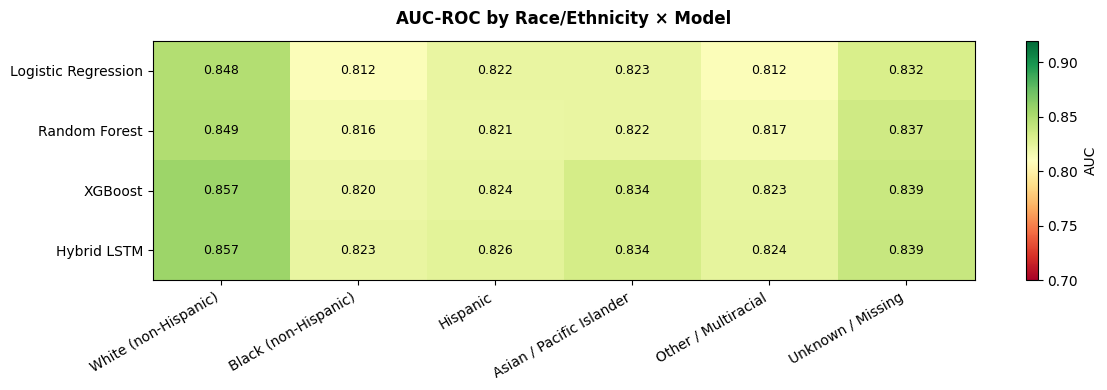

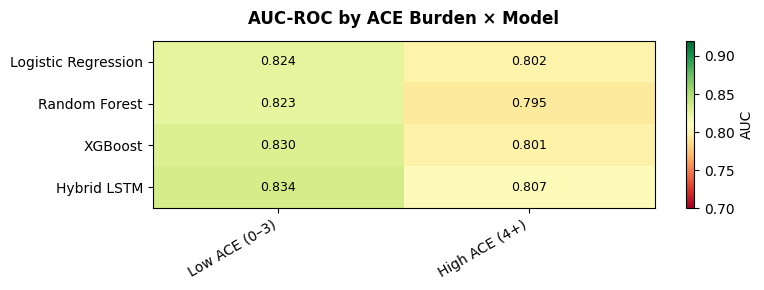

Fairness heatmaps saved.


In [18]:
# CELL 18 — Fairness heatmaps


def plot_fairness_heatmap(df, metric, title, figsize=(10, 4)):
    metric_cols = [c for c in df.columns if c.endswith(f'_{metric}')]
    if not metric_cols:
        print(f"No {metric} columns found.")
        return

    heat_df = df.set_index('group')[metric_cols].copy()
    heat_df.columns = [c.replace(f'_{metric}', '') for c in heat_df.columns]

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(heat_df.values.T, aspect='auto', cmap='RdYlGn',
                   vmin=0.70, vmax=0.92)

    ax.set_xticks(range(len(heat_df.index)))
    ax.set_xticklabels(heat_df.index, rotation=30, ha='right', fontsize=10)
    ax.set_yticks(range(len(heat_df.columns)))
    ax.set_yticklabels(heat_df.columns, fontsize=10)

    for i in range(len(heat_df.index)):
        for j in range(len(heat_df.columns)):
            val = heat_df.values[i, j]
            ax.text(i, j, f'{val:.3f}', ha='center', va='center',
                    fontsize=9, color='black')

    plt.colorbar(im, ax=ax, label=metric)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)
    plt.tight_layout()
    return fig

if '_RACEGR3' in sub.columns and not race_df.empty:
    fig = plot_fairness_heatmap(race_df, 'AUC',
                                'AUC-ROC by Race/Ethnicity × Model',
                                figsize=(12, 4))
    if fig:
        fig.savefig(f"{PROJECT_PATH}/clean_data/fairness_race_auc.png",
                    dpi=150, bbox_inches='tight')
        plt.show()

if 'HIGH_ACE' in sub.columns and not ace_df.empty:
    fig = plot_fairness_heatmap(ace_df, 'AUC',
                                'AUC-ROC by ACE Burden × Model',
                                figsize=(8, 3))
    if fig:
        fig.savefig(f"{PROJECT_PATH}/clean_data/fairness_ace_auc.png",
                    dpi=150, bbox_inches='tight')
        plt.show()

print("Fairness heatmaps saved.")

In [19]:
# CELL 19 — Final summary


print("\n" + "="*65)
print("COLE'S NOTEBOOK COMPLETE")
print("="*65)
print("Files saved to clean_data/:")
print("  model_results.pkl")
print("  fairness_results.pkl")
print("  baseline_roc_pr_curves.png")
print("  fairness_race_auc.png")
print("  fairness_ace_auc.png")


COLE'S NOTEBOOK COMPLETE
Files saved to clean_data/:
  model_results.pkl
  fairness_results.pkl
  baseline_roc_pr_curves.png
  fairness_race_auc.png
  fairness_ace_auc.png
